In [108]:
import cv2
import numpy as np

import torch
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt

# reference to cloned repository
from data.DeepFurniture.deepfurniture import DeepFurnitureDataset

# Data Preprocessing

Download data according to the hugging face descripton: https://huggingface.co/datasets/byliu/DeepFurniture#1-download-and-extraction

In [109]:
# Initialize dataset
dataset = DeepFurnitureDataset("./data/DeepFurniture/uncompressed_data")

print(f"Number of Scenes: {len(dataset)}")

Number of Scenes: 24182


## Depth Data

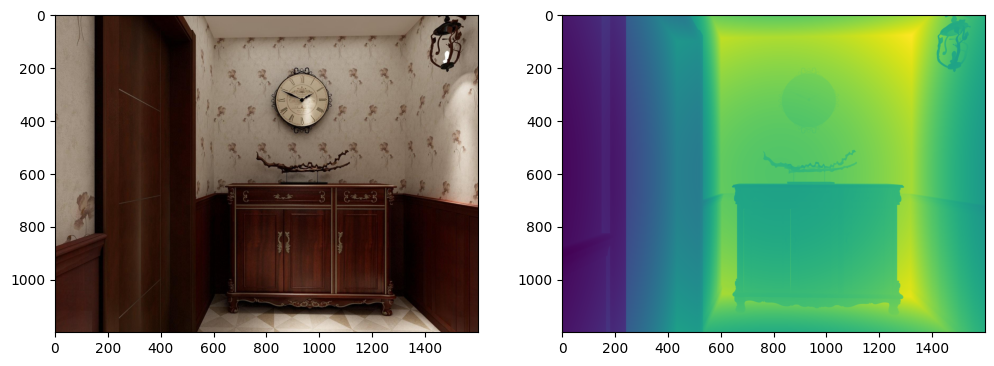

In [110]:
scene = dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(scene['image'])
axes[1].imshow(scene['depth'])

### Image Details

When printing the PIL image, we can extract some important information out of it:

- **mode:I;16** -> depth range is from 0 to 65535 (2¹⁶-1)

In [111]:
print(scene['depth'])

<PIL.PngImagePlugin.PngImageFile image mode=I;16 size=1600x1200 at 0x32CE9F820>


# MiDaS

In [112]:
model_type = "DPT_Large"     # MiDaS v3 - Large     (highest accuracy, slowest inference speed)
#model_type = "DPT_Hybrid"   # MiDaS v3 - Hybrid    (medium accuracy, medium inference speed)
#model_type = "MiDaS_small"  # MiDaS v2.1 - Small   (lowest accuracy, highest inference speed)

midas = torch.hub.load("intel-isl/MiDaS", model_type)

Using cache found in /Users/timon/.cache/torch/hub/intel-isl_MiDaS_master


In [113]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
# device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print(f'selected device: {device}')
midas.to(device)
midas.eval()

print('model ready for evaluation')

selected device: mps
model ready for evaluation


In [114]:
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

if model_type == "DPT_Large" or model_type == "DPT_Hybrid":
    transform = midas_transforms.dpt_transform
else:
    transform = midas_transforms.small_transform

Using cache found in /Users/timon/.cache/torch/hub/intel-isl_MiDaS_master


In [115]:
def compute_midas(image):
    numpy_image = np.array(image)

    # If you want to use it with OpenCV's display functions
    # OpenCV uses BGR format while PIL uses RGB
    # For I;16 mode, you might need to convert to a format cv2 can display well
    if image.mode == 'I;16':
        # Convert to a more standard format
        pil_image_rgb = image.convert('RGB')
        numpy_image = np.array(pil_image_rgb)
        # Convert RGB to BGR (OpenCV format)
        img = cv2.cvtColor(numpy_image, cv2.COLOR_RGB2BGR)
    else:
        # For regular RGB images
        img = cv2.cvtColor(numpy_image, cv2.COLOR_RGB2BGR)

        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    input_batch = transform(img).to(device)
    
    with torch.no_grad():
        prediction = midas(input_batch)

        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=img.shape[:2],
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    return prediction.cpu().numpy()
    

In [116]:
output = compute_midas(scene['image'])

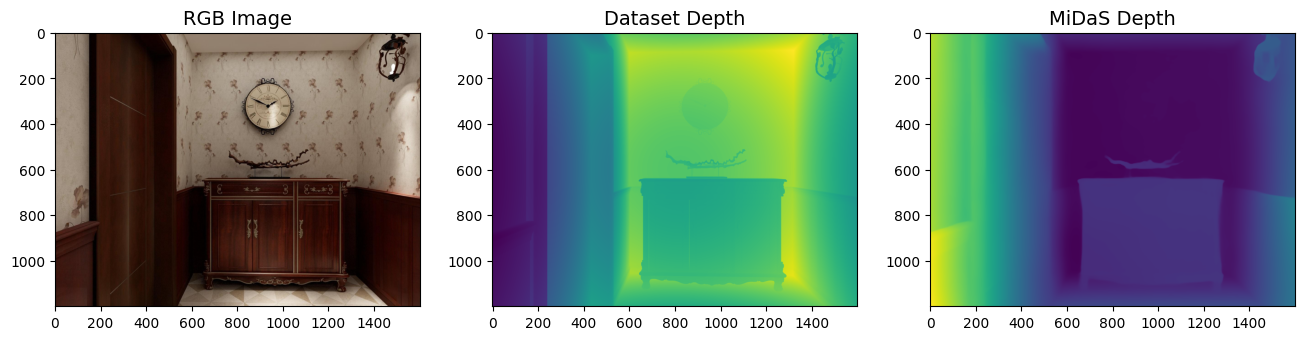

In [117]:
scene = dataset[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 8))

axes[0].set_title('RGB Image', fontsize=14)
axes[0].imshow(scene['image'])

axes[1].set_title('Dataset Depth', fontsize=14)
axes[1].imshow(scene['depth'])

axes[2].set_title('MiDaS Depth', fontsize=14)
axes[2].imshow(output)

# Model Evaluation

## Metrics

The standard metrics for depth estimation are:

- Absolute Relative Error (abs_rel)
- Root Mean Square Error (RMSE)
- RMSE in log space (rmse_log)
- Accuracy under threshold (a1, a2, a3)

In [118]:
# Compute accuracy metrics
def compute_metrics(pred, gt):
    # Create mask for valid pixels
    mask = gt > 0
    
    if mask.sum() == 0:
        return None  # No valid pixels
    
    # Extract valid pixels
    pred = pred[mask]
    gt = gt[mask]
    
    # Scale-invariant error (used in many depth estimation papers)
    diff = np.log(pred) - np.log(gt)
    rmse_log = np.sqrt(np.mean(diff ** 2))
    
    # Absolute relative error
    abs_rel = np.mean(np.abs(pred - gt) / gt)
    
    # Root mean square error
    rmse = np.sqrt(np.mean((pred - gt) ** 2))
    
    # Accuracy metrics: % of pixels with ratio threshold < 1.25^x
    thresh = np.maximum(pred / gt, gt / pred)
    a1 = (thresh < 1.25).mean()
    a2 = (thresh < 1.25**2).mean()
    a3 = (thresh < 1.25**3).mean()
    
    return {
        'rmse_log': rmse_log,
        'abs_rel': abs_rel,
        'rmse': rmse,
        'a1': a1,
        'a2': a2,
        'a3': a3
    }

In [119]:
def print_metrics(metrics):
    if metrics is None:
        print("No valid pixels found for evaluation")
        return
        
    print("\n" + "="*50)
    print(" DEPTH ESTIMATION METRICS ".center(50, "="))
    print("="*50)
    print(f"{'Metric':<20} {'Value':<15}")
    print("-"*50)
    for name, value in metrics.items():
        print(f"{name:<20} {value:.4f}")
    print("="*50 + "\n")

### Align Dephts

MiDaS predictions don't have metric units. The alignment step is crucial for meaningful comparison.

MiDaS outputs inverse depth (disparity), where closer objects have larger values. Ensure the DeepFurniture depth maps follow the same convention or invert one of them for comparison.

In [120]:
# Align scales (since MiDaS produces relative depth)
def align_depths(pred, gt):
    # Option 2: Least squares alignment (more robust)
    # This approximates a linear transformation: pred_aligned = a*pred + b
    mask = gt > 0  # Only consider valid pixels
    if mask.sum() > 0:
        gt_valid = gt[mask]
        pred_valid = pred[mask]
        
        # Solve for a and b using least squares
        A = np.vstack([pred_valid, np.ones(len(pred_valid))]).T
        a, b = np.linalg.lstsq(A, gt_valid, rcond=None)[0]
        
        pred_aligned = a * pred + b
        return pred_aligned
    
    return pred  # Return unaligned if no valid pixels

## Example


============ DEPTH ESTIMATION METRICS ============
Metric               Value          
--------------------------------------------------
rmse_log             0.0931
abs_rel              0.0699
rmse                 176.5941
a1                   0.9796
a2                   0.9970
a3                   1.0000



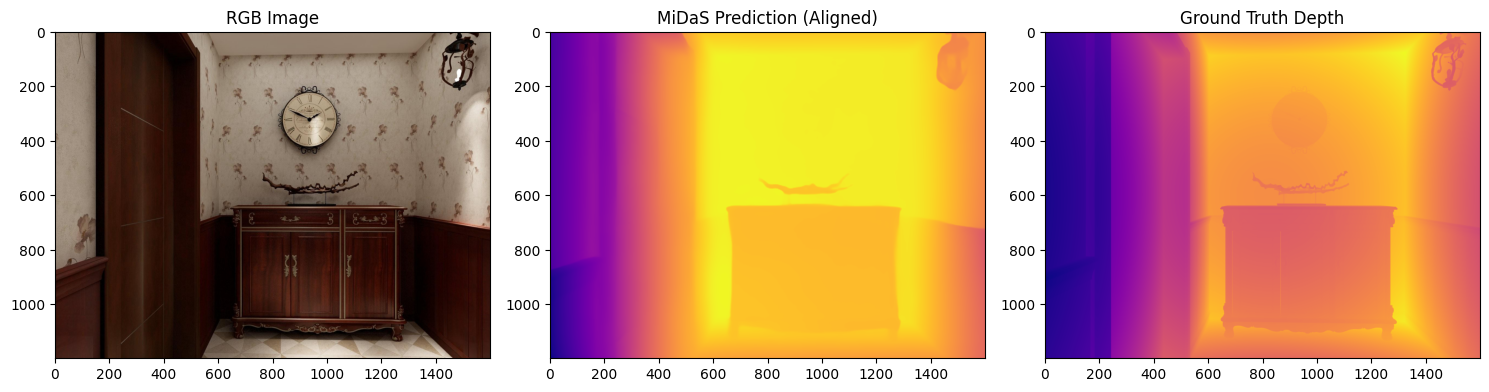

In [121]:
# Load ground truth depth map
gt_depth = np.array(scene['depth'])

# Align MiDaS prediction to ground truth scale
midas_aligned = align_depths(output, gt_depth)

# Calculate metrics
metrics = compute_metrics(midas_aligned, gt_depth)
print_metrics(metrics)

# Visualize results
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(scene['image'])
plt.title('RGB Image')

plt.subplot(132)
plt.imshow(midas_aligned, cmap='plasma')
plt.title('MiDaS Prediction (Aligned)')

plt.subplot(133)
plt.imshow(gt_depth, cmap='plasma')
plt.title('Ground Truth Depth')

plt.tight_layout()
plt.show()

## Dataset Evaluation

Starting MiDaS evaluation on DeepFurniture dataset...
Processed 10/1000 samples. Valid samples: 10


/var/folders/1j/wtq97vbs2pl0w4tb09kq4m1r0000gn/T/ipykernel_69518/1427513308.py:14: RuntimeWarning: invalid value encountered in log
  diff = np.log(pred) - np.log(gt)


Processed 20/1000 samples. Valid samples: 20
Processed 30/1000 samples. Valid samples: 30
Processed 40/1000 samples. Valid samples: 40
Processed 50/1000 samples. Valid samples: 50
Processed 60/1000 samples. Valid samples: 60
Processed 70/1000 samples. Valid samples: 70
Processed 80/1000 samples. Valid samples: 80
Processed 90/1000 samples. Valid samples: 90
Processed 100/1000 samples. Valid samples: 100
Processed 110/1000 samples. Valid samples: 110
Processed 120/1000 samples. Valid samples: 120
Processed 130/1000 samples. Valid samples: 130
Processed 140/1000 samples. Valid samples: 140
Processed 150/1000 samples. Valid samples: 150
Processed 160/1000 samples. Valid samples: 160
Processed 170/1000 samples. Valid samples: 170
Processed 180/1000 samples. Valid samples: 180
Processed 190/1000 samples. Valid samples: 190
Processed 200/1000 samples. Valid samples: 200
Processed 210/1000 samples. Valid samples: 210
Processed 220/1000 samples. Valid samples: 220
Processed 230/1000 samples. V

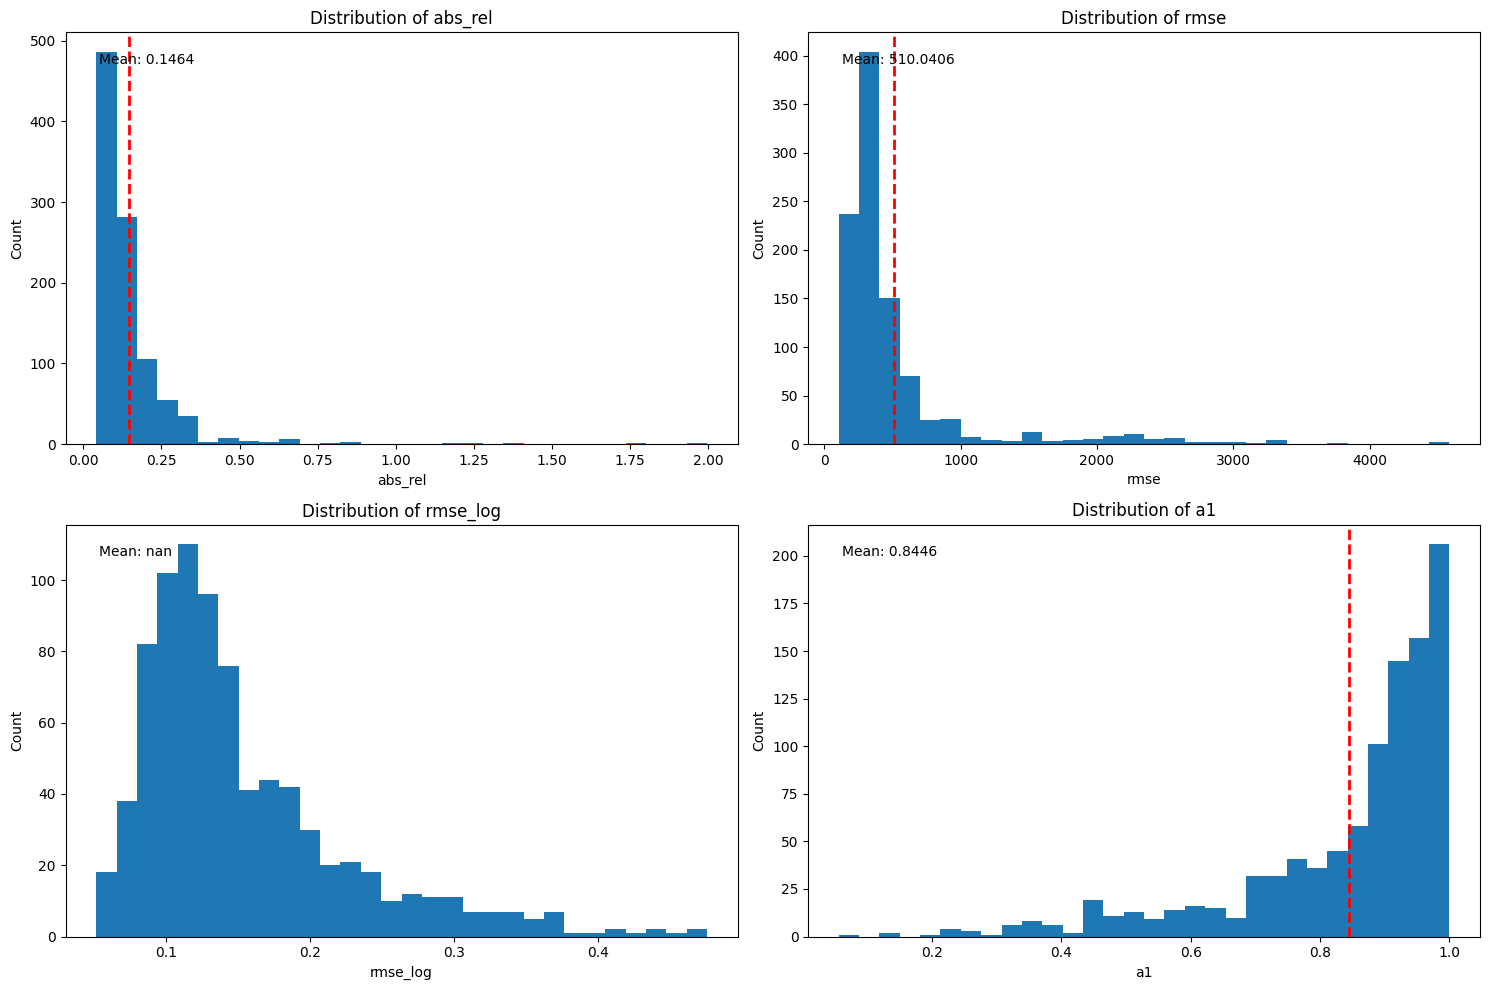

Results saved to midas_evaluation_20250502_111908.json


In [122]:
def evaluate_midas_on_dataset(dataset, model, transform, device, num_samples=None):
    """
    Evaluate MiDaS on the entire dataset or a subset
    
    Args:
        dataset: The DeepFurniture dataset
        model: The MiDaS model
        transform: The appropriate transform for the model
        device: The device to run inference on
        num_samples: Optional limit on number of samples to evaluate
        
    Returns:
        Dictionary of averaged metrics and list of per-sample metrics
    """
    if num_samples is None:
        num_samples = len(dataset)
    else:
        num_samples = min(num_samples, len(dataset))
    
    # Store metrics for each sample
    all_metrics = []
    
    # Accumulators for average metrics
    acc_metrics = {
        'rmse_log': 0,
        'abs_rel': 0,
        'rmse': 0,
        'a1': 0,
        'a2': 0,
        'a3': 0
    }
    
    valid_samples = 0
    
    # Process each sample
    for i in range(num_samples):
        # Get sample
        scene = dataset[i]
        
        # Skip samples without valid depth
        if 'depth' not in scene or scene['depth'] is None:
            continue
        
        # Compute MiDaS prediction
        try:
            midas_prediction = compute_midas(scene['image'])
            
            # Load ground truth depth map
            gt_depth = np.array(scene['depth'])
            
            # Align MiDaS prediction to ground truth scale
            midas_aligned = align_depths(midas_prediction, gt_depth)
            
            # Calculate metrics
            metrics = compute_metrics(midas_aligned, gt_depth)
            
            if metrics is not None:
                all_metrics.append(metrics)
                valid_samples += 1
                
                # Accumulate metrics
                for key in acc_metrics:
                    acc_metrics[key] += metrics[key]
                
                # Print progress
                if (i + 1) % 10 == 0:
                    print(f"Processed {i+1}/{num_samples} samples. Valid samples: {valid_samples}")
                    
        except Exception as e:
            print(f"Error processing sample {i}: {e}")
    
    # Calculate average metrics
    avg_metrics = {}
    if valid_samples > 0:
        for key in acc_metrics:
            avg_metrics[key] = acc_metrics[key] / valid_samples
    
    return avg_metrics, all_metrics

# Main evaluation code
def run_dataset_evaluation():
    print("Starting MiDaS evaluation on DeepFurniture dataset...")
    
    # Set maximum number of samples to evaluate (None for all)
    # Timon MacBook: whole dataset around 5x 25min -> 2.5 hours
    max_samples = 1000  # Change this to None to evaluate all samples
    
    # Run evaluation
    avg_metrics, all_metrics = evaluate_midas_on_dataset(
        dataset=dataset, 
        model=midas, 
        transform=transform, 
        device=device,
        num_samples=max_samples
    )
    
    # Print overall metrics
    print("\nEvaluation complete!")
    print(f"Evaluated on {len(all_metrics)} valid samples")
    print_metrics(avg_metrics)
    
    # Plot histogram of metrics
    plt.figure(figsize=(15, 10))
    
    metrics_to_plot = ['abs_rel', 'rmse', 'rmse_log', 'a1']
    for i, metric in enumerate(metrics_to_plot):
        values = [m[metric] for m in all_metrics]
        
        plt.subplot(2, 2, i+1)
        plt.hist(values, bins=30)
        plt.title(f'Distribution of {metric}')
        plt.xlabel(metric)
        plt.ylabel('Count')
        
        # Add mean line
        plt.axvline(avg_metrics[metric], color='r', linestyle='dashed', linewidth=2)
        plt.text(0.05, 0.95, f'Mean: {avg_metrics[metric]:.4f}', 
                 transform=plt.gca().transAxes, verticalalignment='top')
    
    plt.tight_layout()
    plt.show()
    
    # Save results to file
    import json
    import datetime
    
    # Convert NumPy values to Python native types for JSON serialization
    serializable_avg_metrics = {k: float(v) for k, v in avg_metrics.items()}
    serializable_all_metrics = []
    for metrics_dict in all_metrics:
        serializable_all_metrics.append({k: float(v) for k, v in metrics_dict.items()})
    
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    results = {
        "model_type": model_type,
        "num_samples": len(all_metrics),
        "average_metrics": serializable_avg_metrics,
        "per_sample_metrics": serializable_all_metrics
    }
    
    with open(f"midas_evaluation_{timestamp}.json", "w") as f:
        json.dump(results, f, indent=4)
    
    print(f"Results saved to midas_evaluation_{timestamp}.json")
    
    return avg_metrics, all_metrics

# Run the evaluation
avg_metrics, all_metrics = run_dataset_evaluation()

Evaluation output:

```text
Evaluation complete!
Evaluated on 994 valid samples

==================================================
============ DEPTH ESTIMATION METRICS ============
==================================================
Metric               Value          
--------------------------------------------------
rmse_log             nan
abs_rel              0.1464
rmse                 510.0406
a1                   0.8446
a2                   0.9601
a3                   0.9816
==================================================
```